<a href="https://colab.research.google.com/github/iiLolaii/data-management-262/blob/main/is262_spreadsheet_script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Google Drive access

!pip install gspread google-auth

In [ ]:
from google.colab import auth

In [ ]:
auth.authenticate_user()

In [ ]:
import gspread
from google.auth import default
import pandas as pd

In [ ]:
creds, _ = default()
gc = gspread.authorize(creds)

In [ ]:
#Connect to spreadsheet

sh = gc.open("is262_spreadsheet")
wks = sh.sheet1
records = wks.get_all_records()

In [ ]:
df = pd.DataFrame(records)
df.head()

,doi_url,title,author,journal_name,publication_year,primary_sources,secondary_sources,geographic_location,language,dialect,data_deposited,data_deposit_doi_url,data_repository_format,funding_source,funding_count
0,https://doi.org/10.1017/S0142716423000243,The impact of dialect differences on spoken la...,Arynn S. Byrd;Yi Ting Huang;Jan Edwards,Applied Psycholinguistics,2023,dataset,n/a,america,english,african american english (aae)\nmainstream ame...,other,https://osf.io/w7jhs,OSF,Institute of Education Sciences;\nNational Sci...,Institute of Education Sciences;\nNational Sci...
1,https://doi.org/10.3390/languages6010040,"Language, or Dialect, That Is the Question. Ho...",Astrid Adler,Languages,2021,survey,interview;scholarly article,germany,german,low german,upon request,https://www.diw.de/en/diw_01.c.601584.en/data_...,website,n/a,n/a
2,https://doi.org/10.3390/languages10090242,When Pitch Falls Short: Reinforcing Prosodic B...,Marta Ortega-Llebaria;Jun Nagao,Languages,2025,study,scholarly article,america;japan,japanese,kobayashi;koriyama;tokyo;osaka;northern kanto;...,in si,https://www.mdpi.com/article/10.3390/languages...,PDF,Hewlett International Grant;University of Pitt...,Hewlett International Grant;University of Pitt...
3,https://doi.org/10.3390/languages10090225,Russian–Belarusian Border Dialects and Their “...,Anastasiia Ryko,Languages,2025,study;interview,scholarly article,estonia,russian;belarusian,mogilev–smolensk;khislavichy;trasianka;east sl...,other,https://lingconlab.ru/khislavichi/#!/,website,n/a,n/a
4,https://doi.org/10.3390/languages10080188,Language Contact and Population Contact as Sou...,Jonathan Dunn;Sidney Wong,Languages,2025,study,study;scholarly article,america;new zealand,english,n/a,repository,https://doi.org/10.17605/OSF.IO/GD2KQ,OSF,n/a,n/a


In [ ]:
#standardizing capitalization and semicolons

lowercase_col = ['primary_sources','secondary_sources','geographic_location','language','dialect','data_deposited']
semicolon_replace = df.drop(columns=['doi_url','title','journal_name','publication_year'])

for col in lowercase_col:
  df[col] = df[col].str.lower()

for col in semicolon_replace:
  df[col] = df[col].str.replace(', ',';')
  df[col] = df[col].str.replace('; ',';')

df = df.replace('N/A','n/a')

df.head()

,doi_url,title,author,journal_name,publication_year,primary_sources,secondary_sources,geographic_location,language,dialect,data_deposited,data_deposit_doi_url,data_repository_format,funding_source,funding_count
0,https://doi.org/10.1017/S0142716423000243,The impact of dialect differences on spoken la...,Arynn S. Byrd;Yi Ting Huang;Jan Edwards,Applied Psycholinguistics,2023,dataset,n/a,america,english,african american english (aae)\nmainstream ame...,other,https://osf.io/w7jhs,OSF,Institute of Education Sciences;\nNational Sci...,Institute of Education Sciences;\nNational Sci...
1,https://doi.org/10.3390/languages6010040,"Language, or Dialect, That Is the Question. Ho...",Astrid Adler,Languages,2021,survey,interview;scholarly article,germany,german,low german,upon request,https://www.diw.de/en/diw_01.c.601584.en/data_...,website,n/a,n/a
2,https://doi.org/10.3390/languages10090242,When Pitch Falls Short: Reinforcing Prosodic B...,Marta Ortega-Llebaria;Jun Nagao,Languages,2025,study,scholarly article,america;japan,japanese,kobayashi;koriyama;tokyo;osaka;northern kanto;...,in si,https://www.mdpi.com/article/10.3390/languages...,PDF,Hewlett International Grant;University of Pitt...,Hewlett International Grant;University of Pitt...
3,https://doi.org/10.3390/languages10090225,Russian–Belarusian Border Dialects and Their “...,Anastasiia Ryko,Languages,2025,study;interview,scholarly article,estonia,russian;belarusian,mogilev–smolensk;khislavichy;trasianka;east sl...,other,https://lingconlab.ru/khislavichi/#!/,website,n/a,n/a
4,https://doi.org/10.3390/languages10080188,Language Contact and Population Contact as Sou...,Jonathan Dunn;Sidney Wong,Languages,2025,study,study;scholarly article,america;new zealand,english,n/a,repository,https://doi.org/10.17605/OSF.IO/GD2KQ,OSF,n/a,n/a


In [ ]:
#Standardizing to controlled vocab

#Funding
df['funding_count'] = df['funding_source'].str.replace('; ', ';')
df['funding_source'] = df['funding_source'].str.replace('Not stated', 'n/a')
df['funding_source'] = df['funding_source'].str.replace('No external funding', 'n/a')
df['funding_source'] = df['funding_source'].str.replace('No funding', 'n/a')
df['funding_source'] = df['funding_source'].str.replace('no external funding', 'n/a')

#Primary and Secondary Sources
sources = ['primary_sources','secondary_sources']

for col in sources:
  df[col] = df[col].str.replace('datasets','dataset')
  df[col] = df[col].str.replace('scholarly articles', 'scholarly article')
  df[col] = df[col].str.replace('interviews','interview')
  df[col] = df[col].str.replace('tests','test')
  df[col] = df[col].str.replace('books','book')
  df[col] = df[col].str.replace('field notes','field note')

df['primary_sources'] = df['primary_sources'].str.replace('questionaire', 'survey')

#Data Repository Format
df['data_repository_format'] = df['data_repository_format'].str.replace('Website','website')
df['data_repository_format'] = df['data_repository_format'].str.replace('Github','github')

#Dialects Format
df['dialect'] = df['dialect'].str.replace('not specified','n/a')
df['dialect'] = df['dialect'].str.replace('n/a ','n/a')



In [ ]:
#exploded value counts

journal_name_count = df['journal_name'].value_counts()

publication_year_count = df['publication_year'].value_counts()

split_primary_sources = df['primary_sources'].str.split(';')
exploded_primary_sources = split_primary_sources.explode()
primary_source_count = exploded_primary_sources.value_counts()

split_secondary_sources = df['secondary_sources'].str.split(';')
exploded_secondary_sources = split_secondary_sources.explode()
secondary_source_count = exploded_secondary_sources.value_counts()

split_geographic_location = df['geographic_location'].str.split(';')
exploded_geographic_location = split_geographic_location.explode()
geographic_location_count = exploded_geographic_location.value_counts()

split_languages = df['language'].str.split(';')
exploded_languages = split_languages.explode()
languages_count = exploded_languages.value_counts()

split_dialects = df['dialect'].str.split(';')
exploded_dialects = split_dialects.explode()
dialects_count = exploded_dialects.value_counts()

split_data_deposited = df['data_deposited'].str.split(';')
exploded_data_deposited = split_data_deposited.explode()
data_deposited_count = exploded_data_deposited.value_counts()

split_repo_format = df['data_repository_format'].str.split(';')
exploded_repo_format = split_repo_format.explode()
repo_format_count = exploded_repo_format.value_counts()

split_funding = df['funding_source'].str.split(';')
exploded_funding = split_funding.explode()
funding_count = exploded_funding.value_counts()

journal_name_count
#publication_year_count
#primary_source_count
#secondary_source_count
#geographic_location_count
#languages_count
#dialects_count
#data_deposited_count
#repo_format_count
#funding_count

,count
journal_name,
Theory and Practice in Language Studies,20
Journal of Language Teaching and Research,15
Languages,13
Asian-Pacific Journal of Second and Foreign Language Education,10
Language Resources and Evaluation,7
The Journal of Comparative Germanic Linguistics,5
Language Policy,3
Russian Linguistics,3
Applied Psycholinguistics,1


In [ ]:
#Publisher count

academy_publication = df['journal_name'].str.count('Theory and Practice in Language Studies').sum() + df['journal_name'].str.count('Journal of Language Teaching and Research').sum()
mdpi = df['journal_name'].str.count('Languages').sum()
springer_open = df['journal_name'].str.count('Asian-Pacific Journal of Second and Foreign Language Education').sum()
springer_nature = df['journal_name'].str.count('Language Resources and Evaluation').sum() + df['journal_name'].str.count('The Journal of Comparative Germanic Linguistics').sum() + df['journal_name'].str.count('Language Policy').sum() + df['journal_name'].str.count('Russian Linguistics').sum()
cambridge_core = df['journal_name'].str.count('Applied Psycholinguistics').sum()
elsevier = df['journal_name'].str.count('Cognitive Development').sum()

#print('Academy Publication:',academy_publication,'\nMDPI:',mdpi,'\nSpringerOpen:',springer_open,'\nSpringerNature:',springer_nature,'\nCambridge Core:',cambridge_core,'\nElsevier:',elsevier)

publisher_data = {
    'Publisher': ['Academy Publication', 'MDPI', 'SpringerOpen', 'SpringerNature', 'Cambridge Core', 'Elsevier'],
    'Count': [academy_publication, mdpi, springer_open, springer_nature, cambridge_core, elsevier]
}

df_publisher = pd.DataFrame(publisher_data)

df_publisher.head(6)


,Publisher,Count
0,Academy Publication,35
1,MDPI,13
2,SpringerOpen,10
3,SpringerNature,18
4,Cambridge Core,1
5,Elsevier,1


In [ ]:
#Open Access vs. Hybrid Count

open_access = academy_publication + mdpi + springer_open + cambridge_core

hybrid = springer_nature + elsevier

print('Open Access Journals:',open_access,'\nHybrid Journals:',hybrid)

Open Access Journals: 59 
Hybrid Journals: 19


In [ ]:
#Isolated single languages
single_lang_drop = languages_count[languages_count == 1].index

filtered_languages = languages_count.loc[languages_count != 1]

#Value Count for Single Languages
single_languages = 0

for language_value in languages_count.values:
  if language_value == 1:
    single_languages = single_languages + 1

#Combining single languages to 'other'

filtered_lang_count = filtered_languages.reset_index()
filtered_lang_count.columns = ['Language', 'Count']

filtered_lang_count.loc[len(filtered_lang_count)] = ['other', single_languages]


filtered_lang_count



,Language,Count
0,english,24
1,arabic,14
2,german,6
3,chinese,4
4,russian,3
5,japanese,3
6,javanese,3
7,balinese,3
8,various,3
9,indonesian,3


In [ ]:
#Import matplotlib and numpy
import matplotlib.pyplot as plt
import numpy as np

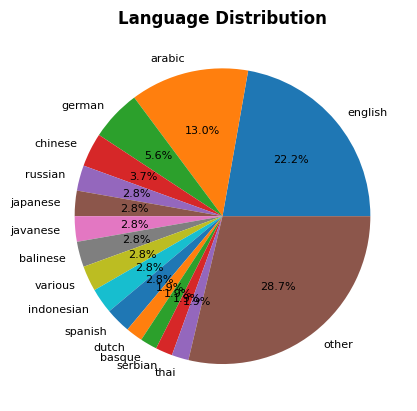

In [ ]:
#Language Pie Chart

filtered_lang_count.plot(
    kind="pie",
    y='Count',
    labels=filtered_lang_count['Language'],
    autopct="%1.1f%%",
    textprops={'fontsize':8}
    )
plt.title('Language Distribution', weight='bold')
plt.ylabel('')
plt.legend('', frameon=False)
plt.show()

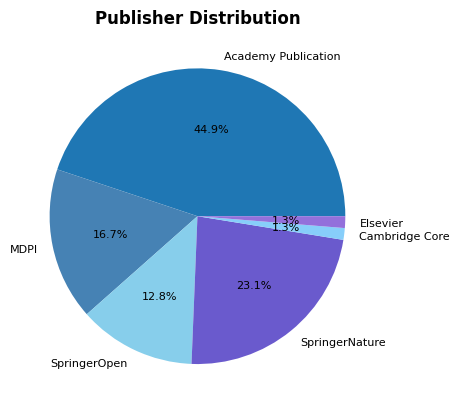

In [ ]:
#Publisher pie chart

publisher_names = ['Academy Publication', 'MDPI', 'SpringerOpen', 'SpringerNature', 'Cambridge Core', 'Elsevier']
publisher_colors = ['tab:blue', 'steelblue', 'skyblue', 'slateblue', 'lightskyblue', 'mediumpurple']

df_publisher.plot(
    kind="pie",
    y='Count',
    labels=publisher_names,
    autopct="%1.1f%%",
    textprops={'fontsize':8},
    colors = publisher_colors
    )
plt.title('Publisher Distribution', weight='bold')
plt.ylabel('')
plt.legend('', frameon=False)
plt.show()

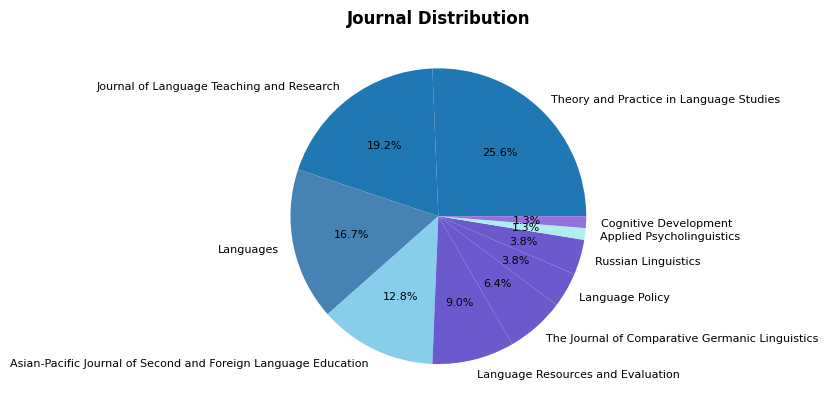

In [ ]:
#Journal Distribution

journal_colors = ["tab:blue", "tab:blue", "steelblue", "skyblue", "slateblue", "slateblue", "slateblue", "slateblue", "paleturquoise", "mediumpurple"]


journal_name_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    textprops={'fontsize':8},
    colors = journal_colors,
    )
plt.title('Journal Distribution', weight='bold')
plt.ylabel('')
plt.show()



In [ ]:
#not funded vs funded

not_funded = df['funding_source'].str.count('n/a').sum()

funded = len(df['funding_source']) - not_funded

print('Funded:',funded,'Not Funded:',not_funded)


Funded: 24 Not Funded: 54


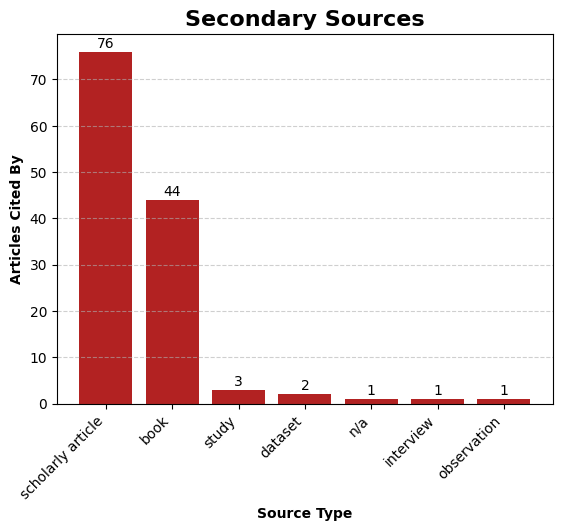

In [ ]:
#Secondary sources bar chart

fig, ax = plt.subplots()
bars = ax.bar(secondary_source_count.index, secondary_source_count.values, color = 'firebrick')

ax.bar_label(bars, padding = 1)
plt.title("Secondary Sources", fontsize=16, weight="bold")
plt.xlabel("Source Type", fontsize=10, weight="bold")
plt.ylabel("Articles Cited By", fontsize=10, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)


plt.show()

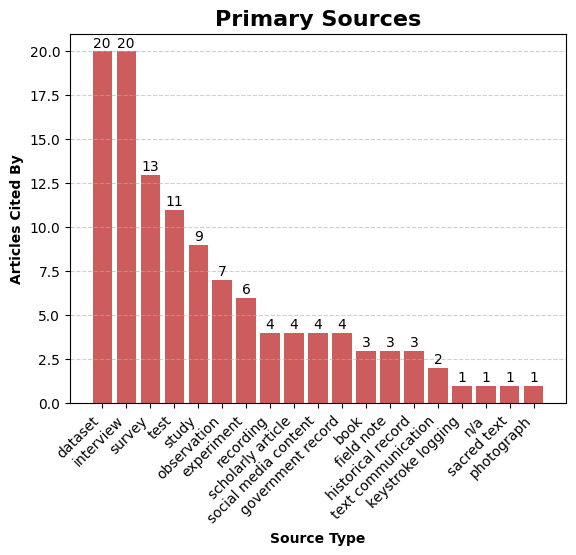

In [ ]:
#Primary source bar chart

fig, ax = plt.subplots()
bars = ax.bar(primary_source_count.index, primary_source_count.values, color = 'indianred')

ax.bar_label(bars, padding = 1)
plt.title("Primary Sources", fontsize=16, weight="bold")
plt.xlabel("Source Type", fontsize=10, weight="bold")
plt.ylabel("Articles Cited By", fontsize=10, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)


plt.show()


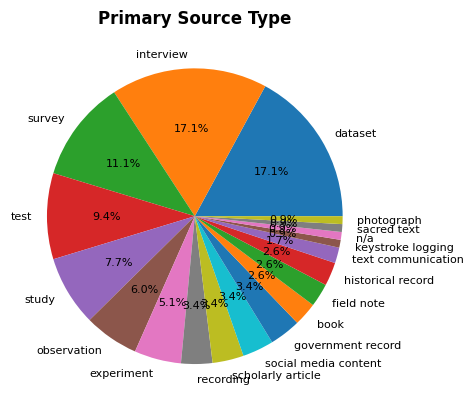

In [ ]:
#Primary Source Pie Chart

primary_source_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    textprops={'fontsize':8}
    )
plt.title('Primary Source Type', weight='bold')
plt.ylabel('')
plt.show()

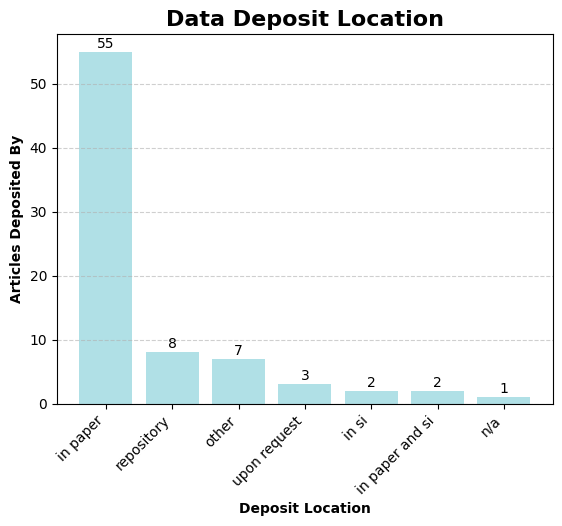

In [ ]:
#Data Deposited Bar Chart

fig, ax = plt.subplots()
bars = ax.bar(data_deposited_count.index, data_deposited_count.values, color = 'powderblue')

ax.bar_label(bars, padding = 1)
plt.title("Data Deposit Location", fontsize=16, weight="bold")
plt.xlabel("Deposit Location", fontsize=10, weight="bold")
plt.ylabel("Articles Deposited By", fontsize=10, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


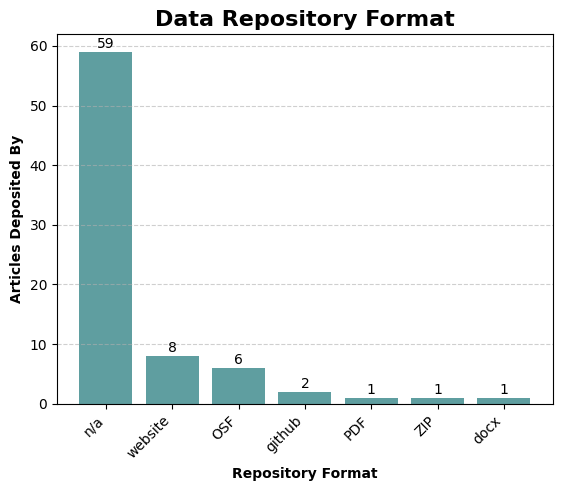

In [ ]:
#Data Repository Format bar chart

fig, ax = plt.subplots()
bars = ax.bar(repo_format_count.index, repo_format_count.values, color = 'cadetblue')

ax.bar_label(bars, padding = 1)
plt.title("Data Repository Format", fontsize=16, weight="bold")
plt.xlabel("Repository Format", fontsize=10, weight="bold")
plt.ylabel("Articles Deposited By", fontsize=10, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)


plt.show()



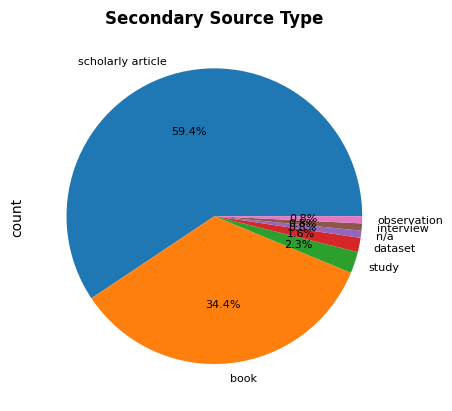

In [ ]:
#Secondary Source pie chart

secondary_source_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    textprops={'fontsize':8}
    )
plt.title('Secondary Source Type', weight='bold')
plt.show()

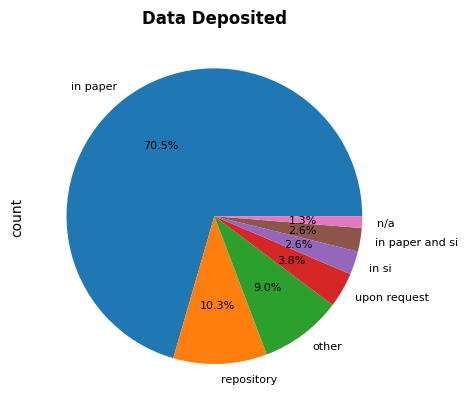

In [ ]:
#Data Deposit Pie Chart

data_deposited_count.plot(
    kind="pie",
    autopct="%1.1f%%",
    textprops={'fontsize':8}
    )
plt.title('Data Deposited', weight='bold')
plt.show()

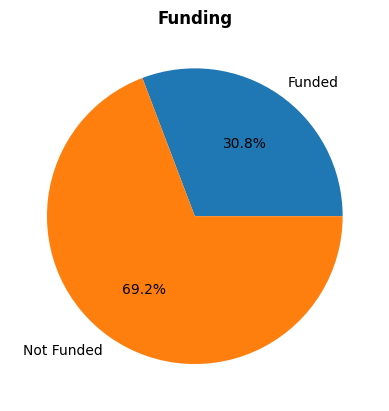

In [ ]:
#Funding pie chart

funding_values = [funded, not_funded]

fig, ax = plt.subplots()
ax.pie(
    funding_values,
    labels=['Funded', 'Not Funded'],
    autopct="%1.1f%%",
    textprops={'fontsize':10}
)
ax.set_title('Funding', weight='bold')
plt.show()

In [ ]:
#Push to spreadsheet

data = [df.columns.values.tolist()] + df.values.tolist()
wks.update(data)

{'spreadsheetId': '1D8r7k6HSKe5kBjayiQULNNp-kWRcoZl8nvi84ctsWLc',
 'updatedRange': 'Sheet1!A1:O79',
 'updatedRows': 79,
 'updatedColumns': 15,
 'updatedCells': 1185}